## First-time setup

**Before opening this notebook**, run the setup script from a terminal. It
lives in `emulator/` and works either way:

```bash
./emulator/setup_emulator.sh        # from repo root
# or
cd emulator && ./setup_emulator.sh
```

It will (idempotently):

1. Prompt **y/N** to build & install **Verilator 5.038** from source.
2. Prompt **y/N** to install **GTKWave**.
3. Create `.venv/` at the repo root, install `qick` (editable) plus `numpy`, `scipy`, `matplotlib`, `ipykernel`, `jupyter`.
4. Register a Jupyter kernel named **`qick-venv`** (display name **Python (qick)**).

Then launch Jupyter from the activated venv so the kernel shows up:

```bash
source .venv/bin/activate
jupyter notebook emulator/notebooks/00_intro_emu_mirrored.ipynb
```

In the notebook: **Kernel ▸ Change Kernel ▸ Python (qick)**, then run the
pip-install + verification cells below.

> Ubuntu prereqs (the script will guide you, but if `python3 -m venv` is unavailable): `sudo apt install python3 python3-venv python3-pip git build-essential`


In [1]:
# Install / refresh notebook deps into the ACTIVE kernel's Python.
# Uses sys.executable (not whatever "pip" is on PATH) so this installs into
# the interpreter actually running this kernel — robust against kernel/PATH
# mismatches. Safe to re-run; pip skips already-satisfied packages.
import sys, subprocess, pathlib

REPO_ROOT = pathlib.Path.cwd().resolve().parent.parent
REQ_FILE  = REPO_ROOT / "emulator" / "requirements.txt"

print(f"installing into: {sys.executable}")
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--quiet", "-r", str(REQ_FILE)]
)
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--quiet", "-e", str(REPO_ROOT)]
)
print("deps installed.")


installing into: /Users/sbf/projects/qick-env/.venv/bin/python



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


deps installed.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# 00_intro — Emulator Edition

This notebook is a 1:1 port of `00_intro.ipynb` that runs against the
Verilator emulator instead of a physical RFSoC. Every cell that would
normally invoke `prog.acquire()` or `prog.acquire_decimated()` against a
live `QickSoc` is replaced with the emulator flow:

```
OUT     = ARTIFACTS_ROOT / '<name>'
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)
iq_list = emu.load_iq_decimated(OUT, prog)   # or load_iq_averaged(...)
```

**Skipped cells:**
- DDR4 buffer cells (`24, 25, 26`) — the TB does not instantiate the DDR4
  buffer IP.
- "Ways to run programs" + scratchwork section (`58+`) — covered by the
  build helpers above.

## Setup

In [2]:
import sys
import importlib
import pathlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# path setup
REPO_ROOT  = pathlib.Path.cwd().parent          # emulator/
source_dir = REPO_ROOT / 'software' / 'source'
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import qick_emu
importlib.reload(qick_emu)          # pick up edits without kernel restart
from qick_emu import QickEmu

from qick.asm_v2 import AveragerProgramV2, QickSpan, QickSweep1D

# emulator init
CFG_PATH = REPO_ROOT / 'notebooks' / 'qick_config_216.json'
emu      = QickEmu(str(CFG_PATH))
soccfg   = emu.soccfg

# artifact root
ARTIFACTS_ROOT = REPO_ROOT / 'artifacts' / '00_intro'
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

# Master switch — set False to skip Verilator runs and re-plot from existing CSVs
RUN_SIM = True

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_ROOT: {ARTIFACTS_ROOT}')
print(soccfg)

QICK library version mismatch: 0.2.366 remote (the board), 0.2.388 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


REPO_ROOT     : /Users/sbf/Desktop/to_verilate/emulator
ARTIFACTS_ROOT: /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro
QICK running on ZCU216, software version 0.2.366

Firmware configuration (built Sat Sep 28 22:15:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-bit DD

In [3]:
# ZCU216 standard firmware channel assignments
GEN_CH    = 0
RO_CH     = 0
TRIG_TIME = 0.40   # us
FREQ      = 100    # MHz

## Basic multi-pulse program

Port of `00_intro.ipynb` cell 10. Five pulses of different styles back-to-back
through a single RO window.

In [4]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)

        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='mygaus', ro_ch=ro_ch,
                       style='arb', envelope='ramp',
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myconst', ro_ch=ro_ch,
                       style='const', length=0.2,
                       freq=cfg['freq'], phase=0, gain=1.0)

        self.add_pulse(ch=gen_ch, name='myflattop2', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.1, phase=90, gain=1.0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # NB: `ddr4=True` is a no-op in the emulator — kept so the program
        # matches the on-hardware version byte-for-byte.
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['gen_ch'], name='myflattop',  t=0)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=0.4)
        self.pulse(ch=cfg['gen_ch'], name='myconst',    t=0.8)
        self.pulse(ch=cfg['gen_ch'], name='myflattop2', t=1.2)
        self.pulse(ch=cfg['gen_ch'], name='mygaus',     t=1.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    1.9,
}

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# emulator artifacts
OUT = ARTIFACTS_ROOT / 'multi_pulse'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)
print(f'Artifacts → {OUT}')

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

Artifacts → /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse


### Simulate & plot (MultiPulse)

[verilate] Building tb_qick_emu_verilator ...
- Verilator: Built from 0.000 MB sources in 0 modules, into 0.000 MB in 0 C++ files needing 0.000 MB
- Verilator: Walltime 0.051 s (elab=0.000, cvt=0.000, bld=0.044); cpu 0.004 s on 8 threads
[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse ...
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/multi_pulse via plusarg ###
### TEST_RUN_TIME overridden to 50 ns ###
### RO_AVG_LEN overridden to 1 via plusarg ###
### RO_DEC_LEN overridden to 584 via plusarg ###
### MR_LEN overridden to 0 via plusarg ###
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.he

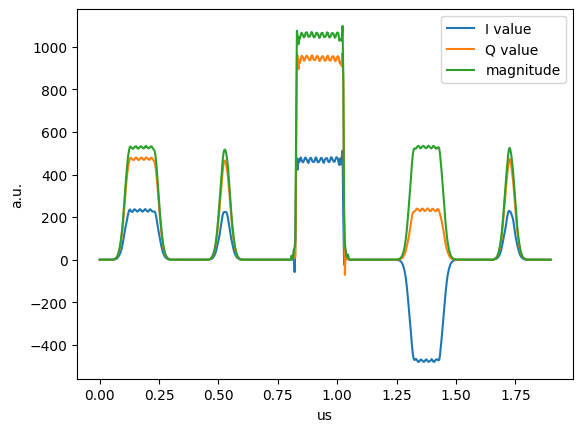

In [5]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=True, test_run_ns = 50) #you can change the test run time here depending on the program you are running

# Decimated I/Q — mirror of cell 10 in 00_intro.ipynb
iq_list = emu.load_iq_decimated(OUT, prog)
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_list[0].shape[0]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_list[0].shape[0], endpoint=False)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [28]:
# print the program (ugly!)
print(prog)

macros:
	Delay(t=1.0, auto=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x11569ea30>}, t_regs={'t': 430})
	ReadWmem(name='mypulse_w0')
	WriteWmem(name='mypulse_w0')
	End()
registers:
pulses:
	mypulse: QickPulse(waveforms=[Waveform(name='mypulse_w0', freq=0, phase=0, env=0, gain=0, length=0, conf=0)])
expanded ASM:
	     NOP 
	     TIME #430 inc_ref 
	     REG_WR r_wave wmem [&0] 
	     WMEM_WR &0 
	     JUMP HERE 


## Basic sweep program

Port of `00_intro.ipynb` cells 13–18.

In [29]:
class SimpleSweepProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=cfg['ramp_len']/10, length=cfg['ramp_len'],
                       even_length=True)
        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

### 5-point phase+gain sweep, plot decimated I

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep  +RO_DEC_LEN=540 +RO_AVG_LEN=5 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emula

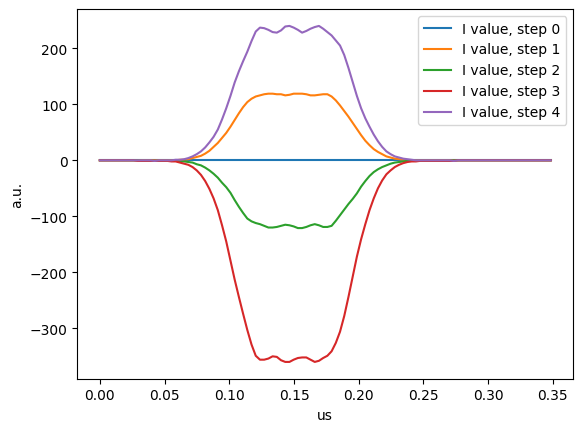

In [30]:
# Port of cell 14
config = {
    'steps':    5,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase':    QickSweep1D('myloop', -360, 720),
    'gain':     QickSweep1D('myloop',  0.0,  1.0),
}

prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]
if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

for ii, iq in enumerate(iq_steps):
    plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(t, iq[:,1], label="Q value, step %d"%(ii))
    # plt.plot(np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [31]:
# print the program
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='myro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x1158eb310>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x1158e8130>}, t_regs={'t': 430})
	OpenLoop(n=1, name='reps')
	OpenLoop(n=5, name='myloop')
	Pulse(ch=0, name='mypulse', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x11585d670>}, t_regs={'t': 0})
	Trigger(ros=[0], tts=[], pins=[0], t=0.4, width=0.023251488095238096, ddr4=False, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x1158e8190>, 'width': <qick.asm_v2.QickParam object at 0x11585dac0>}, t_regs={'t': 172, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 10})
	Wait(t=0, auto=True, gens=False, ros=True, tag=None, no_warn=True, t_params={'t': <qick.asm_v2.QickParam object at 0x11585df40>}, t_regs={'t': 323})
	Delay(t=0.5, auto=True, gens=True, ros=True, ta

### Higher-res sweep with acquire() — I/Q loop

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_highres/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_highres ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_highres  +RO_DEC_LEN=21708 +RO_AVG_LEN=201 +MR_LEN=0
### EMU_DIR set to /Users/s

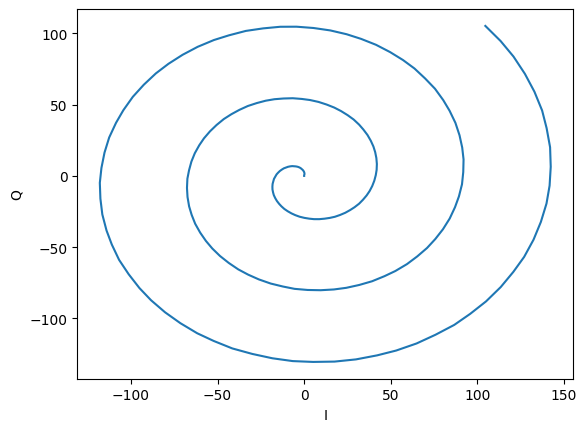

In [32]:
# Port of cell 16. `acquire()` in HW averages over reps × rounds; in the
# emulator we run once and use `load_iq_averaged`, so the plotted curve is
# the single-shot accumulator output (no averaging).
config['steps'] = 201
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep_highres'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq = iq_list[0]
if iq.ndim == 3:
    iq = iq[0]
plt.plot(iq[:,0], iq[:,1])
plt.ylabel("Q")
plt.xlabel("I");

### JSON dump / restore (cell 17)

Pure-Python round-trip; no simulation required.

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_json_roundtrip/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_json_roundtrip ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_json_roundtrip  +RO_DEC_LEN=21708 +RO_AVG_LEN=201 +MR_LEN=0
### EM

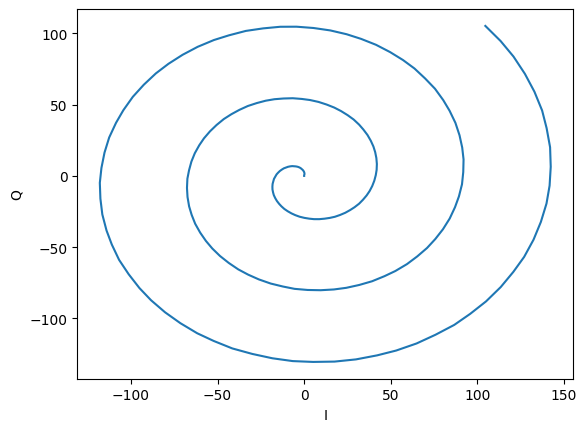

In [33]:
# Port of cell 17 — dump to JSON string and restore.
from qick.asm_v2 import AcquireProgramV2
from qick.helpers import progs2json, json2progs

s = progs2json([prog.dump_prog()])

d = json2progs(s)
newprog = AcquireProgramV2(soccfg)
newprog.load_prog(json2progs(s)[0])

OUT = ARTIFACTS_ROOT / 'simple_sweep_json_roundtrip'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(newprog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, newprog, build=False)

iq_list = emu.load_iq_averaged(OUT, newprog)
iq = iq_list[0]
if iq.ndim == 3:
    iq = iq[0]
plt.plot(iq[:,0], iq[:,1])
plt.ylabel("Q")
plt.xlabel("I");

### Length sweep

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_length/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_length ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/simple_sweep_length  +RO_DEC_LEN=540 +RO_AVG_LEN=5 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desk

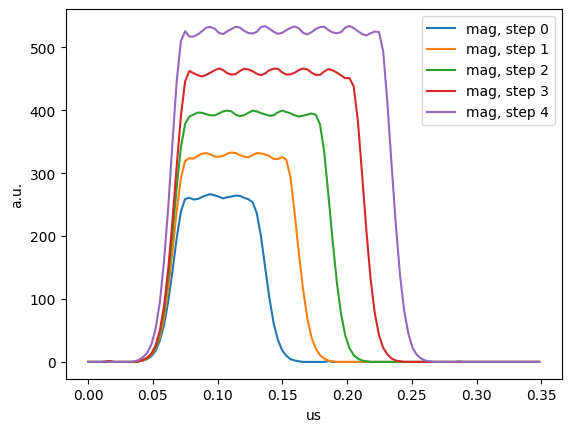

In [34]:
# Port of cell 18 — sweep flat-top length and gain
config = {
    'steps':    5,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': QickSweep1D('myloop', 0.05, 0.15),
    'ramp_len': 0.1,
    'phase':    0,
    'gain':     QickSweep1D('myloop', 0.5, 1.0),
}
prog = SimpleSweepProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'simple_sweep_length'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]
if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

plt.figure(1)
for ii, iq in enumerate(iq_steps):
    # plt.plot(t, iq[:,0], label="I value, step %d"%(ii))
    # plt.plot(t, iq[:,1], label="Q value, step %d"%(ii))
    plt.plot(t, np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

## Multi-dimensional loops and sweeps

Port of `00_intro.ipynb` cells 20, 21, 22, 23. The DDR4 loop-order cells
(24, 25, 26) are skipped — the TB has no DDR4 buffer.

In [39]:
class Sweep2DProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('loop1', self.cfg['steps1'])  # outer
        self.add_loop('loop2', self.cfg['steps2'])  # inner

        self.add_gauss(ch=gen_ch, name='ramp', sigma=cfg['ramp_len']/10,
                       length=cfg['ramp_len'], even_length=True)
        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=cfg['flat_len'],
                       phase=cfg['phase'], gain=cfg['gain'])

        self.delay(0.5)
        self.trigger(ddr4=True, mr=True, t=0)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        # --- FIXED: Shift the timeline forward slightly so DSP register updates can settle ---
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0.05)
        
        # Shift the readout trigger by the exact same amount to stay aligned
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'] + 0.05)
        
        self.delay_auto(0.01)

# --- FIXED: Crank the resolution back up for a smooth gradient ---
config = {
    'steps1':    10,  
    'steps2':    20,  
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.35,
    'flat_len':  0.05,
    'ramp_len':  0.2,
    'phase':     0,
    'gain':      0.4 + QickSpan("loop1", 0.5) + QickSpan("loop2", 0.1),
}

prog = Sweep2DProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# ── generate emulator artifacts ───────────────────────────────────────────────
OUT = ARTIFACTS_ROOT / 'sweep_2d'
OUT.mkdir(parents=True, exist_ok=True)

soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

print(f'\nArtifacts → {OUT}')
for f in sorted(OUT.iterdir()):
    print(f'  {f.name:<25s}  {f.stat().st_size:>8d} bytes')

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------


Artifacts → /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d
  axi_replay.jsonl                644 bytes
  axi_replay.txt                  440 bytes
  dmem.mem                          9 bytes
  mr_out.csv                       56 bytes
  pmem.mem                       1289 bytes
  sgmem_ch0.mem                 12137 bytes
  wmem.mem                        259 bytes


### Gain sweep on both loop levels (cell 21)

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d  +RO_DEC_LEN=21600 +RO_AVG_LEN=200 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d via plusarg ###
### RO_AVG_LEN overridden to 200 via plusarg ###
### RO_DEC_LEN overridden to 21600 via plusarg ###
### MR_LEN overridden to 0 via plusarg ###
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256, WIDTH=32
ROM init from sine_cos_full32.hex: DEPTH=256,

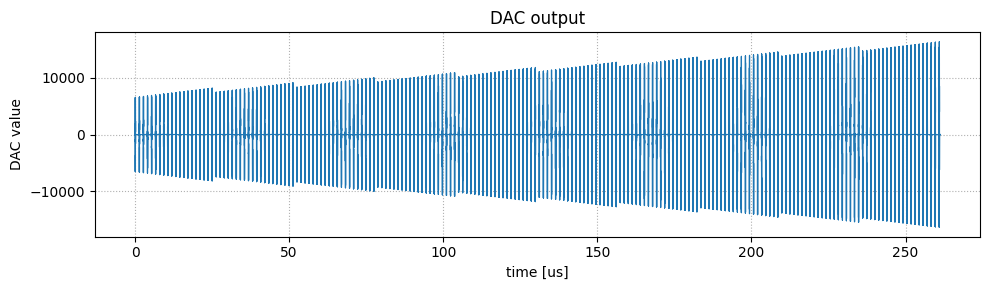

iq_list[0].shape = (1, 10, 20, 2)
loop_dims = [1, 10, 20], avg_level = 0
ro_chs = {0: {'trigs': 1, 'length': 108, 'length_us': 0.3515625, 'edge_counting': False, 'high_threshold': 0, 'low_threshold': 0}}
mag.shape = (10, 20)


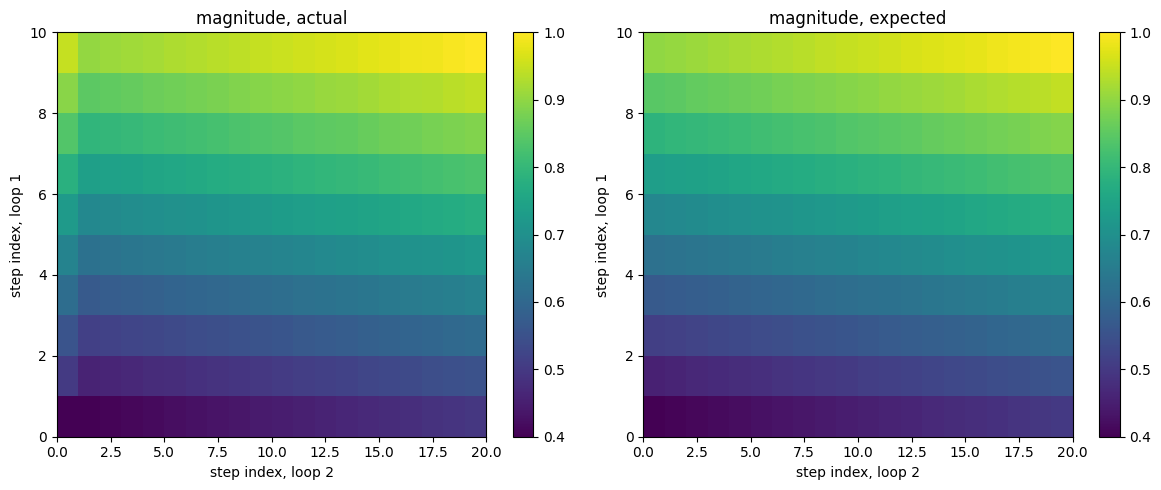

In [40]:
if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

    # DAC waveform
    t_dac, dac = emu.load_dac(OUT)
    plt.figure(figsize=(10, 3))
    plt.plot(t_dac, dac, linewidth=0.8)
    plt.xlabel("time [us]"); plt.ylabel("DAC value"); plt.title("DAC output")
    plt.grid(True, ls=":"); plt.tight_layout(); plt.show()

    # 2D sweep
    iq_list = emu.load_iq_averaged(OUT, prog)
    print(f"iq_list[0].shape = {iq_list[0].shape}")   # <-- diagnostic
    print(f"loop_dims = {prog.loop_dims}, avg_level = {prog.avg_level}")
    print(f"ro_chs = {dict(prog.ro_chs)}")

    # Pick the last trig axis (the acquisition one, not the ddr4/mr setup trig).
    # iq_list[0] shape is (trigs, *loop_dims_after_avg, 2).
    iq_full = iq_list[0]
    if iq_full.ndim == 4:          # (trigs, loop1, loop2, 2) — expected
        iq = iq_full[-1]           # take the last trig (acquisition)
    elif iq_full.ndim == 3:        # (loop1, loop2, 2) — single trig
        iq = iq_full
    else:
        raise ValueError(f"unexpected iq shape {iq_full.shape}")

    mag = np.abs(iq.dot([1, 1j]))
    print(f"mag.shape = {mag.shape}")   # should be (10, 20)

    # (rest of the plotting code unchanged)
    mag_for_scale = mag.copy()
    mag_for_scale[0, 0] = np.nan
    mag_norm = mag / np.nanmax(mag_for_scale)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    p = axes[0]
    plt.colorbar(p.pcolormesh(mag_norm, vmin=0.4, vmax=1.0), ax=p)
    p.set_title("magnitude, actual"); p.set_ylabel("step index, loop 1"); p.set_xlabel("step index, loop 2")
    p = axes[1]
    expected_gain = prog.get_pulse_param("mypulse", "gain", as_array=True)
    plt.colorbar(p.pcolormesh(expected_gain, vmin=0.4, vmax=1.0), ax=p)
    p.set_title("magnitude, expected"); p.set_ylabel("step index, loop 1"); p.set_xlabel("step index, loop 2")
    plt.tight_layout(); plt.show()

In [41]:
# Port of cell 22 — two equivalent ways to query the swept gain grid
print(prog.get_pulse_param('mypulse', 'gain', as_array=True))
print(config['gain'].get_actual_values(prog.loop_dict))

[[0.39998779 0.40523714 0.41048648 0.41573582 0.42098517 0.42623451
  0.43148386 0.4367332  0.44198254 0.44723189 0.45248123 0.45773057
  0.46297992 0.46822926 0.47347861 0.47872795 0.48397729 0.48922664
  0.49447598 0.49972533]
 [0.45553317 0.46078252 0.46603186 0.47128121 0.47653055 0.48177989
  0.48702924 0.49227858 0.49752793 0.50277727 0.50802661 0.51327596
  0.5185253  0.52377464 0.52902399 0.53427333 0.53952268 0.54477202
  0.55002136 0.55527071]
 [0.51107856 0.5163279  0.52157724 0.52682659 0.53207593 0.53732528
  0.54257462 0.54782396 0.55307331 0.55832265 0.563572   0.56882134
  0.57407068 0.57932003 0.58456937 0.58981871 0.59506806 0.6003174
  0.60556675 0.61081609]
 [0.56662394 0.57187328 0.57712263 0.58237197 0.58762131 0.59287066
  0.59812    0.60336935 0.60861869 0.61386803 0.61911738 0.62436672
  0.62961607 0.63486541 0.64011475 0.6453641  0.65061344 0.65586278
  0.66111213 0.66636147]
 [0.62216932 0.62741867 0.63266801 0.63791735 0.6431667  0.64841604
  0.65366538 0.65

### Gain × phase 2D sweep (cell 23)

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d_gain_phase/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d_gain_phase ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/sweep_2d_gain_phase  +RO_DEC_LEN=21600 +RO_AVG_LEN=200 +MR_LEN=0
### EMU_DIR set to /Users/sbf/

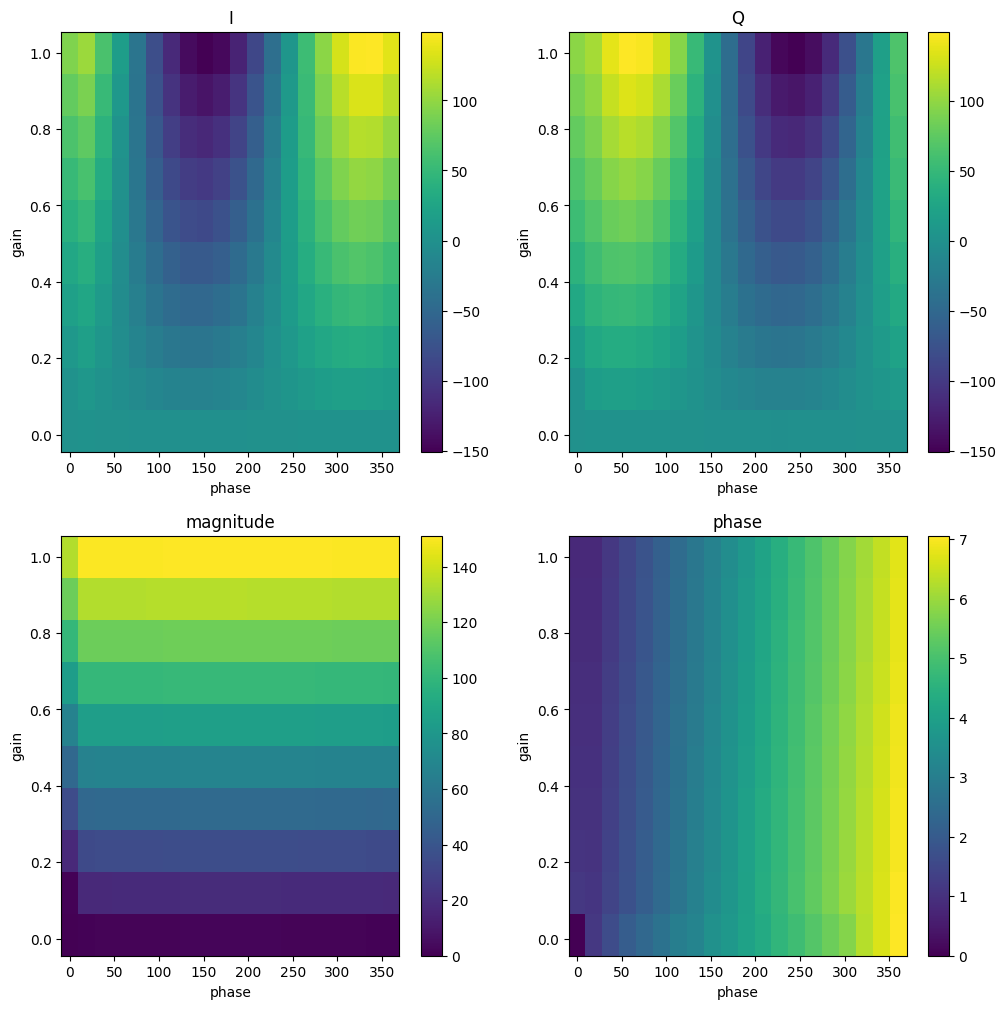

In [61]:
# Port of cell 23. HW version was reps=100, steps1=50, steps2=100; we shrink
# for emulator-friendliness.
config = {
    'steps1':   10,
    'steps2':   20,
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.35,
    'flat_len': 0.05,
    'ramp_len': 0.2,
    'phase':    QickSweep1D('loop2', 0, 360),
    'gain':     QickSweep1D('loop1', 0.01, 1.0),
}
prog = Sweep2DProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'sweep_2d_gain_phase'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq_full = iq_list[0]
if iq_full.ndim == 4:
    iq = iq_full[-1]
elif iq_full.ndim == 3:
    iq = iq_full
else:
    raise ValueError(f'unexpected iq shape {iq_full.shape}')

fig, axes = plt.subplots(2, 2, figsize=(12,12))

# get the exact values of the parameters, after rounding - this also works for scalars (without as_array), you will just get a float
phases = prog.get_pulse_param("mypulse", "phase", as_array=True)
gains = prog.get_pulse_param("mypulse", "gain", as_array=True)

plot = axes[0,0]
plt.colorbar(plot.pcolormesh(phases, gains, iq[:,:,0]), ax=plot)
plot.set_title("I")
plot.set_ylabel("gain")
plot.set_xlabel("phase")
plot = axes[0,1]
plt.colorbar(plot.pcolormesh(phases, gains, iq[:,:,1]), ax=plot)
plot.set_title("Q")
plot.set_ylabel("gain")
plot.set_xlabel("phase")

plot = axes[1,0]
plt.colorbar(plot.pcolormesh(phases, gains, np.abs(iq.dot([1,1j]))), ax=plot)
plot.set_title("magnitude")
plot.set_ylabel("gain")
plot.set_xlabel("phase")

plot = axes[1,1]
plt.colorbar(plot.pcolormesh(phases, gains, np.unwrap(np.angle(iq.dot([1,1j])), axis=1)), ax=plot)
plot.set_title("phase")
plot.set_ylabel("gain")
plot.set_xlabel("phase");

_Cells 24–26 (DDR4 loop-order demo) skipped — TB has no DDR4 buffer IP._

## MR buffer + FFT (cells 27–28)

The MR (Multi-Rate) buffer is the full ADC-rate capture just after the
readout's digital downconversion (pre-FIR / pre-decimation). The Verilator
TB snapshots this bus into `mr_out.csv` when `+MR_LEN=<n>` is passed — we
plumb that through `emu.run_verilator_tb(..., mr_len=N)`.

On-hardware `soc.get_mr()` returns `(N, 2)` I/Q samples; `emu.load_mr(OUT)`
does the same by reading the CSV.

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/mr_capture/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/mr_capture ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/mr_capture  +RO_DEC_LEN=21600 +RO_AVG_LEN=200 +MR_LEN=256
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emula

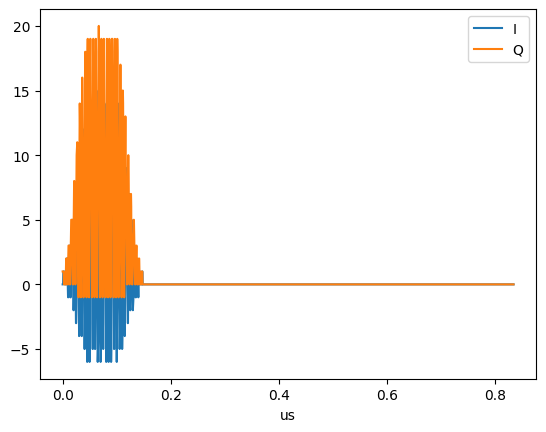

In [43]:
# Port of cell 27 — reuse the Sweep2D program from the previous cell so
# we capture a pulse window. Cap the MR dump at ~128 ro_clk rows
# (= 1024 samples, matching the on-hardware MR depth in the source notebook).
MR_ROWS = 256   # 8 samples per row → 2048 I/Q samples at fs_mr

OUT = ARTIFACTS_ROOT / 'mr_capture'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False, mr_len=MR_ROWS)

t_mr, iq_mr = emu.load_mr(OUT, time_unit='us')

plt.plot(t_mr, iq_mr[:,0],label="I")
plt.plot(t_mr, iq_mr[:,1],label="Q")
plt.xlabel("us")
plt.legend();

Text(0.5, 0, 'MHz')

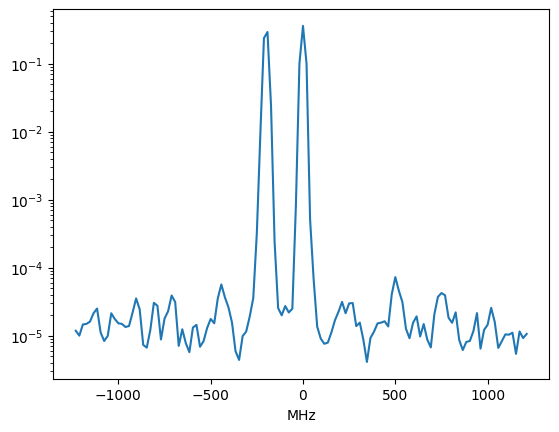

In [44]:
# Port of cell 28 — plot the PSD of the MR buffer I+jQ samples.
# Note: we subtract the downconversion frequency in HW, so the image tone
# shows up at -2f.
from scipy.signal import welch
from numpy.fft import fftshift
fs_mr = soccfg['readouts'][RO_CH]['fs']
fft_freqs, psd = welch(iq_mr.dot([1,1j]), fs_mr, return_onesided=False, nperseg=min(128, iq_mr.shape[0]), detrend=False)
fft_freqs = fftshift(fft_freqs)
psd = fftshift(psd)
plt.semilogy(fft_freqs, psd)
plt.xlabel("MHz")

## Timeline management (cells 30–35)

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/delay_timeline/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/delay_timeline ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/delay_timeline  +RO_DEC_LEN=552 +RO_AVG_LEN=3 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate

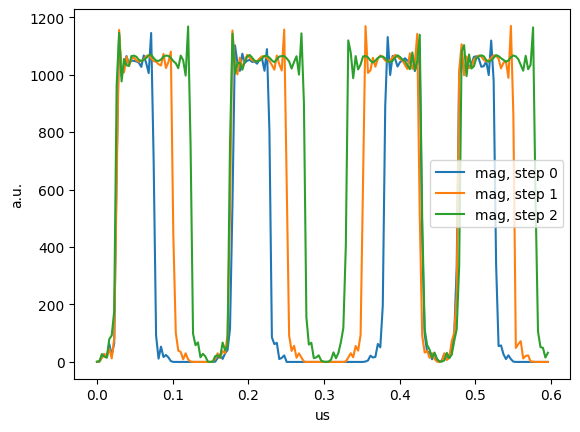

In [66]:
# Port of cell 30 — goofing around with timeline management
class DelayProgram(AveragerProgramV2):
    
    # --- PATCH: Intercept delays and inject them into time_dict ---
    def delay(self, t, tag=None, **kwargs):
        super().delay(t, tag=tag, **kwargs)
        if tag is not None:
            class MockDelay:
                def get_time_param(self, parname): return t
            self.time_dict[tag] = MockDelay()
            
    def delay_auto(self, t, ros=None, tag=None, **kwargs):
        super().delay_auto(t, ros=ros, tag=tag, **kwargs)
        if tag is not None:
            class MockDelay:
                def get_time_param(self, parname): return t
            self.time_dict[tag] = MockDelay()
    # --------------------------------------------------------------

    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'],
                       length=QickSweep1D('myloop', 0.05, 0.1),
                       phase=cfg['phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)
        
        # REQUIRED: Push reference time forward to absorb setup math
        self.delay_auto(1.0)

    def _body(self, cfg):
        # Your exact original body with the original tags!
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], tag='trig')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.delay(0.15, tag='delay1')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.delay_auto(QickSweep1D('myloop', 0.15, 0.05), ros=False, tag='delay2')
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.pulse(ch=cfg['gen_ch'], name='mypulse',
                   t=QickSweep1D('myloop', 0.1, 0.15), tag='pulse4')


config = {
    'gen_ch':   GEN_CH,
    'ro_ch':    RO_CH,
    'freq':     FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':   0.6,
    'phase':    0,
    'gain':     1.0,
    'steps':    3,
}

prog = DelayProgram(soccfg, reps=1, final_delay=1.0, cfg=config)

OUT = ARTIFACTS_ROOT / 'delay_timeline'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq_steps = iq_list[0]

if iq_steps.ndim == 2:
    iq_steps = iq_steps[None, :, :]
t = prog.get_time_axis(ro_index=0)

if len(t) != iq_steps.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_steps.shape[1], endpoint=False)

for ii, iq in enumerate(iq_steps):
    plt.plot(t, np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))
    
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us")
plt.show()

### Timeline introspection (cells 32–35)

Pure Python — no simulation needed.

In [58]:
# Port of cell 32
prog.get_time_param('delay1', 't')

0.15113467261904762

In [59]:
# Port of cell 33 — swept parameters come back as QickParam; use as_array
print(prog.get_time_param('delay2', 't', as_array=True))
print(prog.get_time_param('delay2', 't').to_array(prog.loop_dict))

[0.1999628  0.17671131 0.15345982]
[0.1999628  0.17671131 0.15345982]


In [60]:
# Port of cell 34 — compute the end time of the third pulse
(prog.get_time_param('delay1', 't')
 + prog.get_time_param('delay2', 't')
 + prog.get_pulse_param('mypulse', 'total_length')).to_array(prog.loop_dict)

array([0.4011776 , 0.40296617, 0.40475475])

In [46]:
# Port of cell 35 — discover what pulse params exist
prog.list_pulse_params('mypulse')

['length', 'gain', 'freq', 'phase', 'total_length']

## Feedback (cells 39, 41, 42, 43)

### Tuning the readout latency

Cell 39 measures the phase offset between the generated pulse and the
received readout so the feedback threshold can be set correctly. On hardware
the last two prints depend on `soc.read_mem(...)` which reads the tProc's
data memory *after* a run — the emulator TB does not currently dump the
post-run `dmem` back to the host, so those lines are commented out. The
`phase_offset` value is still computed from the decimated I/Q so the
downstream `FeedbackProgram` cells can use it.

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/read_program/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/read_program ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/read_program  +RO_DEC_LEN=31 +RO_AVG_LEN=1 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emulat

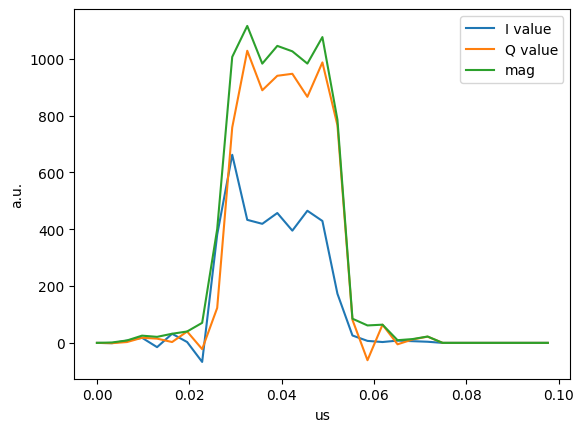

In [10]:
# Port of cell 39 — ReadProgram
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro',
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')


config = {
    'gen_ch':      GEN_CH,
    'ro_ch':       RO_CH,
    'freq':        FREQ,
    'trig_time':   TRIG_TIME,
    'read_wait':   0.1,
    'ro_len':      0.1,
    'pulse_len':   0.025,
    'pulse_phase': 0,
    'ro_phase':    0,
    'gain':        1.0,
}

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'read_program'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq = iq_list[0]
t = prog.get_time_axis(ro_index=0)
if len(t) != iq.shape[0]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq.shape[0], endpoint=False)

plt.plot(t, iq[:,0], label="I value")
plt.plot(t, iq[:,1], label="Q value")
plt.plot(t, np.abs(iq.dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq.sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq.sum(axis=0))
# On-hardware would read back tProc dmem here:
# print("feedback readout:", soc.read_mem(2,'dmem'))

### Using feedback

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_9steps/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_9steps ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_9steps  +RO_DEC_LEN=558 +RO_AVG_LEN=18 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_veri

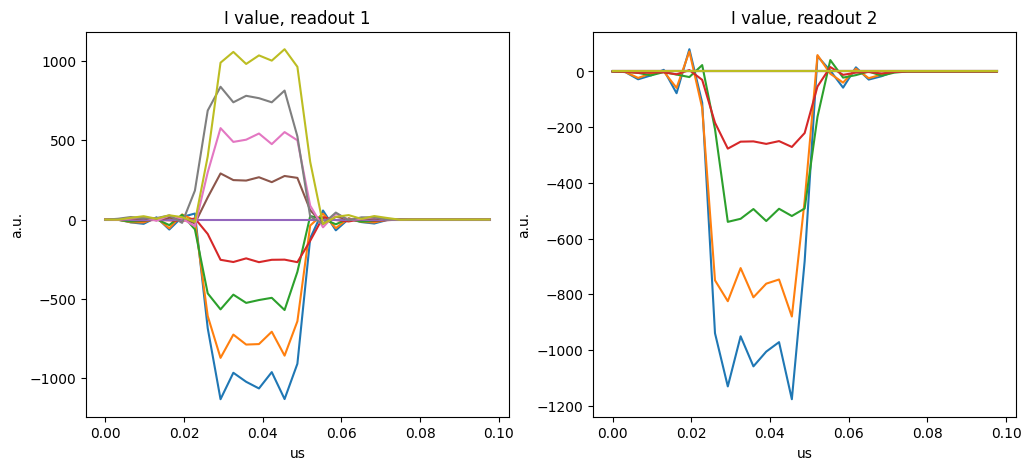

In [9]:
# Port of cell 41 — FeedbackProgram: threshold + conditional jump
class FeedbackProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_loop('myloop', cfg['steps'])

        self.add_pulse(ch=gen_ch, name='mypulse', ro_ch=ro_ch,
                       style='const',
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'], gain=cfg['gain'])

        self.add_readoutconfig(ch=ro_ch, name='myro',
                               freq=cfg['freq'], gen_ch=gen_ch,
                               phase=cfg['ro_phase'])
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)
        
        # Push reference time forward to absorb tProc setup latency
        self.delay_auto(1.0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        self.wait_auto(cfg['read_wait'])
        self.delay_auto(cfg['read_wait'] + cfg['extra_delay'])

        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

        self.read_and_jump(ro_ch=cfg['ro_ch'], component='I',
                           threshold=cfg['threshold'], test='>=', label='NOPULSE')

        self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0)
        self.label('NOPULSE')


config = {
    'steps':       9,
    'gen_ch':      GEN_CH,
    'ro_ch':       RO_CH,
    'freq':        FREQ,
    'trig_time':   TRIG_TIME,
    'read_wait':   0.1,
    'extra_delay': 0.2,
    'threshold':   0,
    'ro_len':      0.1,
    'pulse_len':   0.025,
    'pulse_phase': 0,
    'ro_phase':    -phase_offset,
    'gain':        QickSweep1D('myloop', -1.0, 1.0),
}

prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'feedback_9steps'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
iq_plot = iq_list[0]
t = prog.get_time_axis(ro_index=0)

if iq_plot.ndim == 3:
    iq_plot = iq_plot[:, None, :, :]
if len(t) != iq_plot.shape[2]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, iq_plot.shape[2], endpoint=False)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for iRead in range(2):
    plot = axes[iRead]
    if iRead < iq_plot.shape[1]:
        for ii, iq in enumerate(iq_plot):
            plot.plot(t, iq[iRead,:,0], label="I value, step %d"%(ii))
            # plt.plot(iq[:,1], label="Q value, step %d"%(ii))
            # plt.plot(np.abs(iq.dot([1,1j])), label="mag, step %d"%(ii))

    plot.set_title("I value, readout %d"%(iRead+1))
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_long/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_long ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_long  +RO_DEC_LEN=3100 +RO_AVG_LEN=100 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate

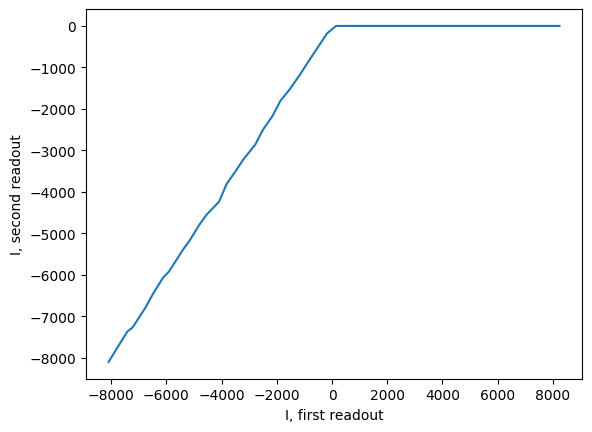

In [12]:
# Port of cell 42 — 50-step gain sweep, first vs second readout
config = {
    'steps':       50,   # shrunk from 200 for emulator runtime
    'gen_ch':      GEN_CH,
    'ro_ch':       RO_CH,
    'freq':        FREQ,
    'trig_time':   TRIG_TIME,
    'read_wait':   0.1,
    'extra_delay': 0.2,
    'threshold':   0,
    'ro_len':      0.1,
    'pulse_len':   0.025,
    'pulse_phase': 0,
    'ro_phase':    -phase_offset,
    'gain':        QickSweep1D('myloop', -1.0, 1.0),
}

prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
gains = prog.get_pulse_param("mypulse", "gain", as_array=True)

OUT = ARTIFACTS_ROOT / 'feedback_long'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq = iq_list[0]

ro_len = len(prog.get_time_axis(ro_index=0))

# multiply the acquired I values by the length of the readout window, to undo length-normalization and get the raw units used for feedback
i_vals = iq[:,:,0]*ro_len
plt.plot(i_vals[0],i_vals[1])

plt.ylabel("I, second readout")
plt.xlabel("I, first readout")
plt.show()

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_threshold/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_threshold ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/feedback_threshold  +RO_DEC_LEN=3100 +RO_AVG_LEN=100 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desk

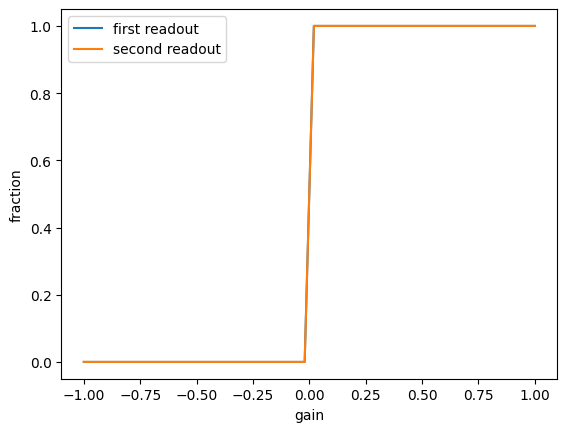

In [13]:
# Port of cell 43 — thresholded readout (not actually feedback)
# In HW this uses `prog.acquire(soc, threshold=0, angle=0)`. The emulator
# `load_iq_averaged` does not apply the thresholding, so we reproduce it
# manually: take sign(I) over the two readouts.
prog = FeedbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'feedback_threshold'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_averaged(OUT, prog)
iq = iq_list[0]
binary = (iq[:,:,0] >= 0).astype(float)
plt.plot(gains, binary[0], label="first readout")
plt.plot(gains, binary[1], label="second readout")
plt.legend()
plt.ylabel("fraction")
plt.xlabel("gain");

## Register operations (cell 45)

Demonstrates `set_ext_counter`, `write_dmem`, `read_dmem`, `inc_reg`. On
hardware this needs `soc.read_mem(...)` and `soc.get_tproc_counter(...)`
post-run, which the emulator TB doesn't expose — so we print the text ASM
and run the program through the TB, but skip the read-back lines.

In [17]:
# Port of cell 45 — register ops, dmem read/write
from qick.asm_v2 import QickProgramV2
prog = QickProgramV2(soccfg)
prog.add_reg(name='myaddr')

prog.set_ext_counter(addr=1, val=1000)
prog.set_ext_counter(addr=2, val=1000)
prog.write_reg(dst='myaddr', src=2)

prog.write_dmem(addr=3, src=10)
prog.read_dmem(dst='s_core_w1', addr=3)

prog.write_dmem(addr='myaddr', src=17)
prog.read_dmem(dst='s_core_w2', addr='myaddr')

prog.inc_reg(dst='myaddr', src=-1)
prog.write_dmem(addr='myaddr', src=19)
prog.end()

print('text ASM:')
print(prog.asm())

# On hardware:
#   soc.load_mem([1,2,3,4,5], 'dmem')
#   prog.run(soc)
#   print(soc.read_mem(5, 'dmem'))
#   print(soc.get_tproc_counter(1))
#   print(soc.get_tproc_counter(2))
# Emulator has no readback path for dmem / tproc counters yet.

text ASM:
     NOP 
     REG_WR s12 imm #1000 
     REG_WR s13 imm #1000 
     REG_WR r0 imm #2 
     DMEM_WR [&3] imm #10 
     REG_WR s12 dmem [&3] 
     DMEM_WR [&r0] imm #17 
     REG_WR s13 dmem [&r0] 
     REG_WR r0 op -op(r0 + #-1) 
     DMEM_WR [&r0] imm #19 
     JUMP HERE 



## Pulse updates, subroutines (cells 47–48)

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update  +RO_DEC_LEN=552 +RO_AVG_LEN=2 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/emula

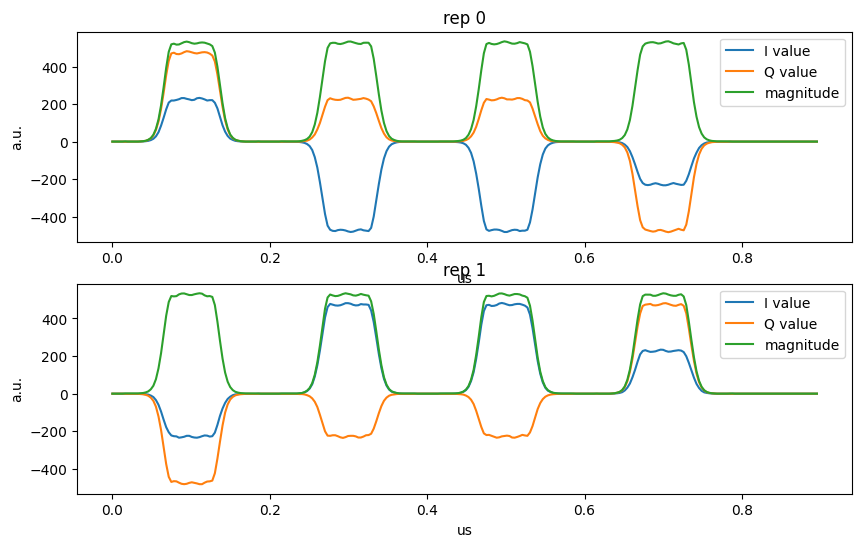

In [18]:
# Port of cell 47 — virtual-Z subroutine applied mid-program
from qick.asm_v2 import AsmV2

class PulseUpdateProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)

        sub = AsmV2()
        for wname in self.list_pulse_waveforms('myflattop'):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=cfg['gen_ch']))
            sub.write_wmem(name=wname)
        self.add_subroutine('virt_z', sub)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.2)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.4)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.6)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.9,
}
prog = PulseUpdateProgram(soccfg, reps=2, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'pulse_update'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
t = prog.get_time_axis(ro_index=0)
data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
if len(t) != data.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, data.shape[1], endpoint=False)

fig, axes = plt.subplots(len(data), 1, figsize=(10,6))
if len(data) == 1:
    axes = [axes]

for ii, iq in enumerate(data):
    plot = axes[ii]

    plot.plot(t, iq[:,0], label="I value")
    plot.plot(t, iq[:,1], label="Q value")
    plot.plot(t, np.abs(iq.dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_title("rep %d"%(ii))
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

[ok] Wrote /Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update2/axi_replay.txt  (9 transactions)

--- tb_qick_emu.sv address routing parameters ---
# Paste these localparam values into tb_qick_emu.sv if defaults differ:
localparam integer TPROC_BASE  = 32'h40260000;
localparam integer SG_BASE_LO  = 32'h40020000;  // 16 gen IP(s)
localparam integer SG_BASE_HI  = 32'h40120000;
localparam integer AVG_BASE_LO = 32'h40130000;  // 10 avgbuf IP(s)
localparam integer AVG_BASE_HI = 32'h40260000;
-------------------------------------------------

[sim] Running simulation with EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update2 ...
cp -f ../../../emulator/models/sig_gen_dds/LUT_generator/*.hex .
cp -f ../../../emulator/models/fir/fir_coe.txt .
./obj_dir/Vtb_qick_emu_verilator +EMU_DIR=/Users/sbf/Desktop/to_verilate/emulator/artifacts/00_intro/pulse_update2  +RO_DEC_LEN=552 +RO_AVG_LEN=2 +MR_LEN=0
### EMU_DIR set to /Users/sbf/Desktop/to_verilate/em

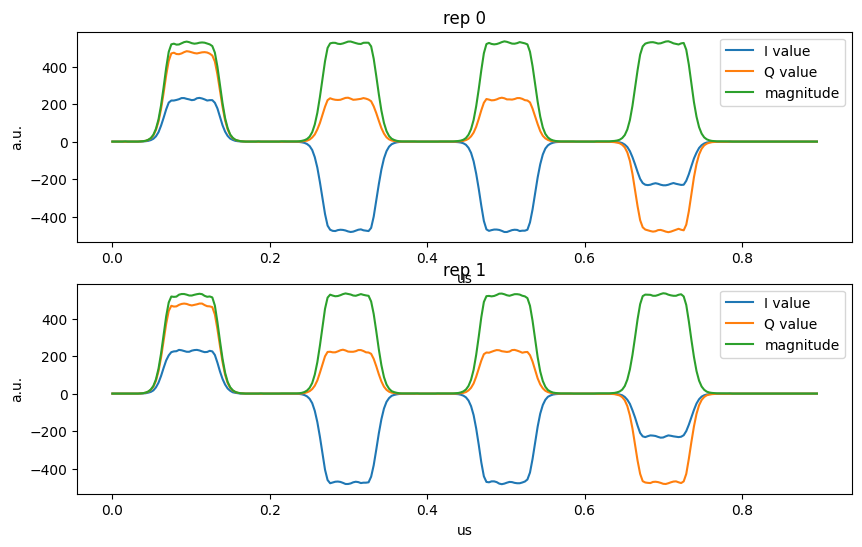

In [14]:
# Port of cell 48 — like 47 but resets w_phase back to 0 at end of body
from qick.asm_v2 import AsmV2

class PulseUpdateProgram2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch  = cfg['ro_ch']
        gen_ch = cfg['gen_ch']

        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.1
        self.add_gauss(ch=gen_ch, name='ramp',
                       sigma=ramp_len/10, length=ramp_len, even_length=True)
        self.add_pulse(ch=gen_ch, name='myflattop', ro_ch=ro_ch,
                       style='flat_top', envelope='ramp',
                       freq=cfg['freq'], length=0.05, phase=0, gain=1.0)

        sub = AsmV2()
        for wname in self.list_pulse_waveforms('myflattop'):
            sub.read_wmem(name=wname)
            sub.inc_reg(dst='w_phase', src=self.deg2reg(90, gen_ch=cfg['gen_ch']))
            sub.write_wmem(name=wname)
        self.add_subroutine('virt_z', sub)

        self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch)
        self.send_readoutconfig(ch=ro_ch, name='myro', t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.2)
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.4)
        self.call('virt_z')
        self.pulse(ch=cfg['gen_ch'], name='myflattop', t=0.6)

        # reset the phase to 0
        for wname in self.list_pulse_waveforms('myflattop'):
            self.read_wmem(name=wname)
            self.write_reg(dst='w_phase', src=0)
            self.write_wmem(name=wname)


config = {
    'gen_ch':    GEN_CH,
    'ro_ch':     RO_CH,
    'freq':      FREQ,
    'trig_time': TRIG_TIME,
    'ro_len':    0.9,
}
prog = PulseUpdateProgram2(soccfg, reps=2, final_delay=0.5, cfg=config)

OUT = ARTIFACTS_ROOT / 'pulse_update2'
OUT.mkdir(parents=True, exist_ok=True)
soc_emu = emu.make_soc(memdir=OUT)
prep    = emu.prepare(prog, soc_emu, memdir=OUT)
emu.export_vivado_files(memdir=OUT)

if RUN_SIM:
    emu.run_verilator_tb(OUT, prog, build=False)

iq_list = emu.load_iq_decimated(OUT, prog)
t = prog.get_time_axis(ro_index=0)
data = iq_list[0] if iq_list[0].ndim == 3 else iq_list[0][None, ...]
if len(t) != data.shape[1]:
    ro_len_us = list(prog.ro_chs.values())[0]['length_us']
    t = np.linspace(0, ro_len_us, data.shape[1], endpoint=False)

fig, axes = plt.subplots(len(data), 1, figsize=(10,6))
if len(data) == 1:
    axes = [axes]

for ii, iq in enumerate(data):
    plot = axes[ii]

    plot.plot(t, iq[:,0], label="I value")
    plot.plot(t, iq[:,1], label="Q value")
    plot.plot(t, np.abs(iq.dot([1,1j])), label="magnitude")
    plot.legend()
    plot.set_title("rep %d"%(ii))
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us");

## Understanding ASM and program structure (cells 51–57)

Pure pedagogy — no simulation.

In [19]:
# Port of cell 51 — print the last program we ran
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='myro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x11569eee0>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x11569ef70>}, t_regs={'t': 430})
	OpenLoop(n=2, name='reps')
	Trigger(ros=[0], tts=[], pins=[0], t=0.4, width=0.023251488095238096, ddr4=True, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x11569efa0>, 'width': <qick.asm_v2.QickParam object at 0x115696190>}, t_regs={'t': 172, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 9, 10})
	Pulse(ch=0, name='myflattop', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x115696040>}, t_regs={'t': 0})
	AsmInst(inst={'CMD': 'CALL', 'LABEL': 'virt_z'}, addr_inc=1)
	Pulse(ch=0, name='myflattop', t=0.2, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0x1156961f0>}, t_regs={'t': 86})
	Pulse(ch=0, name='myflattop', t=

In [20]:
# Port of cell 52
prog.prog_list

[{'P_ADDR': 1, 'LINE': 0, 'CMD': 'NOP'},
 {'CMD': 'REG_WR',
  'DST': 's12',
  'SRC': 'imm',
  'LIT': '#0',
  'P_ADDR': 1,
  'LINE': 1},
 {'CMD': 'WPORT_WR',
  'DST': '4',
  'SRC': 'wmem',
  'ADDR': '&3',
  'TIME': '@0',
  'P_ADDR': 2,
  'LINE': 2},
 {'CMD': 'TIME', 'C_OP': 'inc_ref', 'LIT': '#430', 'P_ADDR': 3, 'LINE': 3},
 {'CMD': 'REG_WR',
  'DST': 'r0',
  'SRC': 'imm',
  'LIT': '#0',
  'P_ADDR': 4,
  'LINE': 4},
 {'CMD': 'TRIG',
  'SRC': 'set',
  'DST': '0',
  'TIME': '@172',
  'P_ADDR': 5,
  'LINE': 5},
 {'CMD': 'TRIG',
  'SRC': 'set',
  'DST': '9',
  'TIME': '@172',
  'P_ADDR': 6,
  'LINE': 6},
 {'CMD': 'TRIG',
  'SRC': 'set',
  'DST': '10',
  'TIME': '@172',
  'P_ADDR': 7,
  'LINE': 7},
 {'CMD': 'TRIG',
  'SRC': 'clr',
  'DST': '0',
  'TIME': '@182',
  'P_ADDR': 8,
  'LINE': 8},
 {'CMD': 'TRIG',
  'SRC': 'clr',
  'DST': '9',
  'TIME': '@182',
  'P_ADDR': 9,
  'LINE': 9},
 {'CMD': 'TRIG',
  'SRC': 'clr',
  'DST': '10',
  'TIME': '@182',
  'P_ADDR': 10,
  'LINE': 10},
 {'CMD': 'WPO

In [21]:
# Port of cell 54 — text ASM ↔ machine code ↔ ASM dicts round-trip
from qick.tprocv2_assembler import Assembler

pstr = 'TIME #384 inc_ref\nREG_WR r_wave wmem [&0]\nWMEM_WR [&0]\n.END'
print('text ASM:')
print(pstr)

print('\nmachine code:')
for a in Assembler.str_asm2bin(pstr)[1]:
    print([hex(b) for b in a])

print('\nASM dicts:')
plist, labels = Assembler.str_asm2list(pstr)
for a in plist:
    print(a)
for a in labels.items():
    print(a)

print('\ntext ASM → ASM dicts → text ASM:')
print(Assembler.list2asm(plist, labels))

text ASM:
TIME #384 inc_ref
REG_WR r_wave wmem [&0]
WMEM_WR [&0]
.END

machine code:
['0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0']
['0xc000', '0x8000000', '0x4c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0x9c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0xbe', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x8000', '0x3c', '0x0', '0x0', '0x0', '0x0', '0x0']

ASM dicts:
{'P_ADDR': 1, 'LINE': 2, 'CMD': 'NOP'}
{'P_ADDR': 1, 'LINE': 1, 'LIT': '#384', 'CMD': 'TIME', 'C_OP': 'inc_ref'}
{'P_ADDR': 2, 'LINE': 2, 'ADDR': '&0', 'CMD': 'REG_WR', 'DST': 'r_wave', 'SRC': 'wmem'}
{'P_ADDR': 3, 'LINE': 3, 'CMD': 'WMEM_WR', 'DST': '[&0]'}
{'LINE': 4, 'P_ADDR': 4, 'ADDR': '&4', 'CMD': 'JUMP'}
('s15', 's15')

text ASM → ASM dicts → text ASM:
     NOP 
     TIME #384 inc_ref 
     REG_WR r_wave wmem [&0] 
     WMEM_WR [&0] 
     JUMP HERE 



In [22]:
# Port of cell 55 — same program using asm_inst
from qick.asm_v2 import QickProgramV2
prog = QickProgramV2(soccfg)
prog.asm_inst({'CMD': 'TIME',    'C_OP': 'inc_ref', 'LIT': '#384'})
prog.asm_inst({'CMD': 'REG_WR',  'DST': 'r_wave',   'SRC': 'wmem', 'ADDR': '&0'})
prog.asm_inst({'CMD': 'WMEM_WR', 'DST': '[&0]'})
prog.end()
print('text ASM:')
print(prog.asm())

print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

text ASM:
     NOP 
     TIME #384 inc_ref 
     REG_WR r_wave wmem [&0] 
     WMEM_WR [&0] 
     JUMP HERE 

machine code:
['0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0']
['0xc000', '0x8000000', '0x4c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0x9c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0xbe', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x8000', '0x3c', '0x0', '0x0', '0x0', '0x0', '0x0']


In [23]:
# Port of cell 56 — same program using macro objects
from qick.asm_v2 import QickProgramV2, Waveform, ReadWmem, WriteWmem, Delay

prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.append_macro(Delay(t=1.0, auto=False))
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.append_macro(ReadWmem(name=wname))
    prog.append_macro(WriteWmem(name=wname))
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

text ASM:
     NOP 
     TIME #430 inc_ref 
     REG_WR r_wave wmem [&0] 
     WMEM_WR &0 
     JUMP HERE 

machine code:
['0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0']
['0xd700', '0x8000000', '0x4c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0x9c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0xbe', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x8000', '0x3c', '0x0', '0x0', '0x0', '0x0', '0x0']


In [24]:
# Port of cell 57 — same program using macro methods (most common style)
from qick.asm_v2 import QickProgramV2, Waveform

prog = QickProgramV2(soccfg)
prog.add_raw_pulse('mypulse', [Waveform(0, 0, 0, 0, 0, 0)])
prog.delay(1.0)
for wname in prog.list_pulse_waveforms('mypulse'):
    prog.read_wmem(name=wname)
    prog.write_wmem(name=wname)
prog.end()

print('text ASM:')
print(prog.asm())
print('machine code:')
prog.compile()
for a in prog.binprog['pmem']:
    print([hex(b) for b in a])

text ASM:
     NOP 
     TIME #430 inc_ref 
     REG_WR r_wave wmem [&0] 
     WMEM_WR &0 
     JUMP HERE 

machine code:
['0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0', '0x0']
['0xd700', '0x8000000', '0x4c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0x9c', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x40000000', '0xbe', '0x0', '0x0', '0x0', '0x0', '0x0']
['0x0', '0x8000', '0x3c', '0x0', '0x0', '0x0', '0x0', '0x0']
